### Классификация новостей по категориям Lenta.ru
Вариант 2.

Выполняли: Билалова И,  Еникеев Т.

Задачи:
1. Анализ датасета и выбор признаков
2. Предварительная обработка текстов
3. Тематическое моделирование (WordCloud + LDA)
4. Векторизация
5. Классификация (3 модели + оценка качества)
6. Парсинг данных 
7. Разработка API 
8. Разработка приложения
9. Документация
10. Итоговый отчет

### Импорт библиотек

In [13]:
import pandas as pd
import numpy as np
import json
import re
import os
import warnings
warnings.filterwarnings('ignore')

In [14]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from pymorphy3 import MorphAnalyzer
import pymorphy3

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
!pip install gensim
import gensim

# import joblib
# nltk.download('stopwords', quiet=True)

### Загрузка и анализ датасета

In [17]:
df = pd.read_csv(r'C:\Users\тимур\Downloads\lenta-ru-news.csv\lenta-ru-news.csv') 

In [18]:
df.head()

,url,title,text,topic,tags,date
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,Бои у Сопоцкина и Друскеник закончились отступ...,Библиотека,Первая мировая,1914/09/16
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова от...,"Министерство народного просвещения, в виду про...",Библиотека,Первая мировая,1914/09/16
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в...",Библиотека,Первая мировая,1914/09/17
3,https://lenta.ru/news/1914/09/17/bulldogn/,1914. Бульдог-гонец под Льежем,Фотограф-корреспондент Daily Mirror рассказыва...,Библиотека,Первая мировая,1914/09/17
4,https://lenta.ru/news/1914/09/18/zver/,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передаю...",Библиотека,Первая мировая,1914/09/18


### Описание набора данных
* **URL**  Cсылка новостной статьи
* **TITLE**  Заголовок  статьи
* **TEXT**  Текст  статьи
* **TOPIC**  Тема  статьи
* **TAGS**  Теги  статьи
* **DATE**  Дата публикации  статьи

In [19]:
# Размер датасета 
df.shape

(800975, 6)

In [20]:
# Информация о колонках
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800975 entries, 0 to 800974
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     800975 non-null  object
 1   title   800975 non-null  object
 2   text    800970 non-null  object
 3   topic   738973 non-null  object
 4   tags    773756 non-null  object
 5   date    800975 non-null  object
dtypes: object(6)
memory usage: 36.7+ MB


Размер датасета 800975 записей, тип данных object

#### Обрезаем датасет на 300,000 новостей.

In [21]:
 df = df.sample(300000, random_state=42)

In [22]:
df.shape

(300000, 6)

In [23]:
df.isnull().sum()

url          0
title        0
text         1
topic    23149
tags     10226
date         0
dtype: int64

In [24]:
# пропущены значения в text (1), topic (23149) и tags(10226)

**Объединяем заголовок и текст** 

In [25]:
df['full_text'] = df['title'].fillna('') + ". " + df['text'].fillna('')

##### **Выбор признаков**

In [26]:
# Оставляем только значимые поля
selected_columns = ['full_text', 'topic']
df_selected = df[selected_columns].copy()

# Удаляем строки с пропусками в тексте
df_selected = df_selected.dropna(subset=['full_text', 'topic'])

print(f"Размер после очистки: {df_selected.shape} \n")
print(f"Категории: {df_selected['topic'].unique()}")

Размер после очистки: (276851, 2) 

Категории: ['Культура' 'Наука и техника' 'Мир' 'Интернет и СМИ' 'Россия' 'Из жизни'
 'Экономика' 'Спорт' 'Бывший СССР' 'Силовые структуры' 'Дом' 'Бизнес'
 'Путешествия' '69-я параллель' 'Ценности' 'Крым' 'Легпром'
 'Культпросвет ' 'Библиотека' 'МедНовости' 'ЧМ-2014' 'Оружие']


##### Выбранные атрибуты:
1. text - Основной источник информации для классификации. Содержит ключевые слова и контекст
2. topic - Целевая переменная (метка класса)
##### Исключенные поля:
1. url - Уникальный идентификатор, не несет смысловой нагрузки для классификации
2. title - Коррелирует с текстом, может внести шум
3. tags	- Часто отсутствует
4. date	- Временная метка не влияет на тематику новости

### Анализ исходного датасета

**Исходные данные:**
- Количество записей: 800975
- Период публикаций: 1914 — 2026 год
- Признаки: `url`, `title`, `text`, `topic`, `tags`, `date`

**Пропущенные значения:**
- `text`: 5 записей
- `topic`: 23149 записей
- `tags`: 10226 записей

**После предварительной очистки:**
- Сделана случайная выборка 300000 записей
- Объединены `title` + `text` в поле `full_text`
- Удалены записи с пропусками в `topic`
- Оставлены только категории, содержащие минимум 50 примеров
- Итоговый размер датасета: **276777** новостей
- Количество целевых категорий: **17**

In [27]:
print("\nРаспределение категорий: ")
print(df_selected['topic'].value_counts())


Распределение категорий: 
topic
Россия               60022
Мир                  51108
Экономика            29877
Спорт                24041
Культура             20192
Бывший СССР          20031
Наука и техника      19804
Интернет и СМИ       16966
Из жизни             10344
Дом                   8078
Силовые структуры     7298
Ценности              2985
Бизнес                2792
Путешествия           2382
69-я параллель         475
Крым                   254
Культпросвет           128
Легпром                 41
Библиотека              29
ЧМ-2014                  2
МедНовости               1
Оружие                   1
Name: count, dtype: int64


In [28]:
# Удаляем категории с очень малым количеством примеров (< 50)
# Это улучшит качество моделей
category_counts = df_selected['topic'].value_counts()
categories_to_keep = category_counts[category_counts >= 50].index.tolist()
df_filtered = df_selected[df_selected['topic'].isin(categories_to_keep)]

In [29]:
print("\nРаспределение категорий после фильтрации:")
print(df_filtered['topic'].value_counts())
print(f"Новый размер датасета: {df_filtered.shape}")


Распределение категорий после фильтрации:
topic
Россия               60022
Мир                  51108
Экономика            29877
Спорт                24041
Культура             20192
Бывший СССР          20031
Наука и техника      19804
Интернет и СМИ       16966
Из жизни             10344
Дом                   8078
Силовые структуры     7298
Ценности              2985
Бизнес                2792
Путешествия           2382
69-я параллель         475
Крым                   254
Культпросвет           128
Name: count, dtype: int64
Новый размер датасета: (276777, 2)


In [30]:
# Сохраним отфильтрованный датасет для дальнейшей работы
df_filtered.to_csv('lenta_filtered.csv', index=False)

In [31]:
df_filtered = pd.read_csv('lenta_filtered.csv') 

### Предварительная обработка текстов

### Предварительная обработка текстов

**Этапы обработки:**

1. Приведение текста к нижнему регистру
2. Удаление специальных символов и неразрывных пробелов
3. Удаление пунктуации
4. Лемматизация с помощью `pymorphy3` + кэширование (`lru_cache`)
5. Токенизация с помощью `nltk.word_tokenize`
6. Удаление расширенного списка стоп-слов (более 200 слов)
7. Фильтрация токенов: длина > 2 символов, только буквы

In [32]:
df_filtered['full_text'][0]

'Жена Оззи Осборна выиграла суд против британского таблоида. Жена лидера британской группы Black Sabbath Оззи Осборна Шэрон выиграла суд против таблоида The Sun. Об этом сообщает издание New Musical Express. Представители издания согласились с решением суда и признали, что нанесли семье Осборнов моральный вред, напечатав статью о методах, которыми пользовалась Осборн во время работы менеджером Black Sabbath. Речь идет о публикации, появившейся в The Sun в октябре 2007 года. Автор текста утверждал, что Шэрон "практически уничтожила своего немощного мужа", а также подвергла его жизнь риску, заставляя работать в напряженном режиме. В статье также рассказывается, что жена Осборна настаивала на том, чтобы музыкант давал живые концерты тогда, когда он был не в лучшей форме. В тексте публикации утверждается, что фронтмен Black Sabbath должен был таким образом заработать деньги, чтобы его супруга могла "продолжать свои непомерные траты". Согласно решению суда, The Sun возместит семье Осборнов 

In [33]:
df_filtered['full_text'][6300]

'Финская старушка до\xa0смерти напугала лосенка. 300-килограммовый лосенок в пятницу ворвался в дом 75-летней жительницы Финляндии, сообщает Reuters. По сообщению полиции, старушка собиралась выпить утренний кофе на кухне своего дома, когда разъяренное животное пробило дверь террасы и пронеслось мимо нее в гостиную. Оказавшись в доме, лосенок начал крушить мебель. "Скорее всего лосенок увидел свое отражение в стекле террасы, принял его за соперника и атаковал", - заявил представитель местной полиции Эро Коскинен (Eero Koskinen). В течение четырех часов полиция и представители общества охраны дикой природы пытались выманить животное на улицу, однако лосенок отказывался покидать дом старушки.  В итоге полиции пришлось выстрелить в животное капсулой с транквилизатором. Усыпленный лосенок был отвезен в ближайший лес. Однако через некоторое время животное было найдено мертвым. "Эта игра оказалось для него слишком жестокой" - заявил Коскинен. Хозяйка дома была доставлена в состоянии шока в м

In [34]:
# формирование корпуса
df_filtered['corpus'] = df_filtered['full_text'].fillna('').astype(str)

In [35]:
st = '\n—\xa0'
def remove_othersymbol(text):
    return ''.join([ch if ch not in st else ' ' for ch in text])

In [36]:
df_filtered['prep_text']= [remove_othersymbol(text.lower()) for text in df_filtered['corpus']]

In [37]:
df_filtered['full_text'][0]

'Жена Оззи Осборна выиграла суд против британского таблоида. Жена лидера британской группы Black Sabbath Оззи Осборна Шэрон выиграла суд против таблоида The Sun. Об этом сообщает издание New Musical Express. Представители издания согласились с решением суда и признали, что нанесли семье Осборнов моральный вред, напечатав статью о методах, которыми пользовалась Осборн во время работы менеджером Black Sabbath. Речь идет о публикации, появившейся в The Sun в октябре 2007 года. Автор текста утверждал, что Шэрон "практически уничтожила своего немощного мужа", а также подвергла его жизнь риску, заставляя работать в напряженном режиме. В статье также рассказывается, что жена Осборна настаивала на том, чтобы музыкант давал живые концерты тогда, когда он был не в лучшей форме. В тексте публикации утверждается, что фронтмен Black Sabbath должен был таким образом заработать деньги, чтобы его супруга могла "продолжать свои непомерные траты". Согласно решению суда, The Sun возместит семье Осборнов 

In [38]:
df_filtered['full_text'][6300]

'Финская старушка до\xa0смерти напугала лосенка. 300-килограммовый лосенок в пятницу ворвался в дом 75-летней жительницы Финляндии, сообщает Reuters. По сообщению полиции, старушка собиралась выпить утренний кофе на кухне своего дома, когда разъяренное животное пробило дверь террасы и пронеслось мимо нее в гостиную. Оказавшись в доме, лосенок начал крушить мебель. "Скорее всего лосенок увидел свое отражение в стекле террасы, принял его за соперника и атаковал", - заявил представитель местной полиции Эро Коскинен (Eero Koskinen). В течение четырех часов полиция и представители общества охраны дикой природы пытались выманить животное на улицу, однако лосенок отказывался покидать дом старушки.  В итоге полиции пришлось выстрелить в животное капсулой с транквилизатором. Усыпленный лосенок был отвезен в ближайший лес. Однако через некоторое время животное было найдено мертвым. "Эта игра оказалось для него слишком жестокой" - заявил Коскинен. Хозяйка дома была доставлена в состоянии шока в м

In [39]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [40]:
def remove_punctuation(text):
    return ''.join([ch for ch in text if ch not in string.punctuation])

In [41]:
df_filtered['prep_text']= [remove_punctuation(text) for text in df_filtered['prep_text']]

In [42]:
df_filtered['prep_text'][0]

'жена оззи осборна выиграла суд против британского таблоида жена лидера британской группы black sabbath оззи осборна шэрон выиграла суд против таблоида the sun об этом сообщает издание new musical express представители издания согласились с решением суда и признали что нанесли семье осборнов моральный вред напечатав статью о методах которыми пользовалась осборн во время работы менеджером black sabbath речь идет о публикации появившейся в the sun в октябре 2007 года автор текста утверждал что шэрон практически уничтожила своего немощного мужа а также подвергла его жизнь риску заставляя работать в напряженном режиме в статье также рассказывается что жена осборна настаивала на том чтобы музыкант давал живые концерты тогда когда он был не в лучшей форме в тексте публикации утверждается что фронтмен black sabbath должен был таким образом заработать деньги чтобы его супруга могла продолжать свои непомерные траты согласно решению суда the sun возместит семье осборнов моральный вред а также из

In [43]:
df_filtered.head()

,full_text,topic,corpus,prep_text
0,Жена Оззи Осборна выиграла суд против британск...,Культура,Жена Оззи Осборна выиграла суд против британск...,жена оззи осборна выиграла суд против британск...
1,В Осло вручили международную премию Абеля по м...,Наука и техника,В Осло вручили международную премию Абеля по м...,в осло вручили международную премию абеля по м...
2,Сбивший полицейского российский дипломат покин...,Мир,Сбивший полицейского российский дипломат покин...,сбивший полицейского российский дипломат покин...
3,Рен ТВ сменил слоган и эфирное оформление. Тел...,Интернет и СМИ,Рен ТВ сменил слоган и эфирное оформление. Тел...,рен тв сменил слоган и эфирное оформление теле...
4,Госдуме предложили не пускать в Россию мигрант...,Россия,Госдуме предложили не пускать в Россию мигрант...,госдуме предложили не пускать в россию мигрант...


#### Лемматизация

In [44]:
import nltk
russian_stopwords = stopwords.words("russian") 

In [45]:
russian_stopwords = set(stopwords.words("russian"))
russian_stopwords.update([
    'т.д.', 'т', 'д', 'это', 'который', 'свой', 'своём', 'всем', 'всё', 'её',
    'оба', 'ещё', 'так', 'весь', 'быть', 'мочь', 'сказать'
])

In [46]:
nltk.download('punkt_tab', quiet=True)

True

In [47]:
morph = pymorphy3.MorphAnalyzer(lang='ru')  #Создается объект morph для лемматизации.

In [48]:
##Лемитизация с кжшом

from functools import lru_cache

@lru_cache(maxsize=50000)
def lemmatize_word(word):
    return morph.parse(word)[0].normal_form

lemm_texts_list = []
for text in df_filtered['prep_text']:
    try:
        tokens = word_tokenize(text)
        lemm_texts_list.append(" ".join(lemmatize_word(w) for w in tokens))
    except:
        lemm_texts_list.append("")

In [49]:
df_filtered['text_lemm'] = lemm_texts_list

In [50]:
df_filtered.head()

,full_text,topic,corpus,prep_text,text_lemm
0,Жена Оззи Осборна выиграла суд против британск...,Культура,Жена Оззи Осборна выиграла суд против британск...,жена оззи осборна выиграла суд против британск...,жена оззь осборн выиграть суд против британски...
1,В Осло вручили международную премию Абеля по м...,Наука и техника,В Осло вручили международную премию Абеля по м...,в осло вручили международную премию абеля по м...,в осло вручить международный премия абель по м...
2,Сбивший полицейского российский дипломат покин...,Мир,Сбивший полицейского российский дипломат покин...,сбивший полицейского российский дипломат покин...,сбить полицейский российский дипломат покинуть...
3,Рен ТВ сменил слоган и эфирное оформление. Тел...,Интернет и СМИ,Рен ТВ сменил слоган и эфирное оформление. Тел...,рен тв сменил слоган и эфирное оформление теле...,рен тв сменить слоган и эфирный оформление тел...
4,Госдуме предложили не пускать в Россию мигрант...,Россия,Госдуме предложили не пускать в Россию мигрант...,госдуме предложили не пускать в россию мигрант...,госдума предложить не пускать в россия мигрант...


In [51]:
df_filtered['text_lemm'][0]

'жена оззь осборн выиграть суд против британский таблоид жена лидер британский группа black sabbath оззь осборн шэрон выиграть суд против таблоид the sun о это сообщать издание new musical express представитель издание согласиться с решение суд и признать что нанести семья осборн моральный вред напечатать статья о метод который пользоваться осборн в время работа менеджер black sabbath речь идти о публикация появиться в the sun в октябрь 2007 год автор текст утверждать что шэрон практически уничтожить свой немощный муж а также подвергнуть он жизнь риск заставлять работать в напрячь режим в статья также рассказываться что жена осборн настаивать на тот чтобы музыкант давать живой концерт тогда когда он быть не в хороший форма в текст публикация утверждаться что фронтмен black sabbath должный быть такой образ заработать деньга чтобы он супруг мочь продолжать свой непомерный трата согласно решение суд the sun возместить семья осборн моральный вред а также издержка сумма который не разглашат

In [52]:
def tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords and len(token) > 2]
    text = " ".join(tokens)
    return text

**Разбиваем на слова удаляем список стоп-слов и слова длиной 2 символа**

In [88]:
df_filtered['tokenize_text'] = [tokenize(text) for text in df_filtered['text_lemm']]

In [89]:
df_filtered['clean_text'] = df_filtered['tokenize_text']

In [90]:
df_filtered.head()

,full_text,topic,corpus,prep_text,text_lemm,tokenize_text,clean_text,tokenize_text3
0,Жена Оззи Осборна выиграла суд против британск...,Культура,Жена Оззи Осборна выиграла суд против британск...,жена оззи осборна выиграла суд против британск...,жена оззь осборн выиграть суд против британски...,жена оззь осборн выиграть суд против британски...,жена оззь осборн выиграть суд против британски...,"[жена, оззь, осборн, выиграть, суд, против, бр..."
1,В Осло вручили международную премию Абеля по м...,Наука и техника,В Осло вручили международную премию Абеля по м...,в осло вручили международную премию абеля по м...,в осло вручить международный премия абель по м...,осло вручить международный премия абель матема...,осло вручить международный премия абель матема...,"[осло, вручить, международный, премия, абель, ..."
2,Сбивший полицейского российский дипломат покин...,Мир,Сбивший полицейского российский дипломат покин...,сбивший полицейского российский дипломат покин...,сбить полицейский российский дипломат покинуть...,сбить полицейский российский дипломат покинуть...,сбить полицейский российский дипломат покинуть...,"[сбить, полицейский, российский, дипломат, пок..."
3,Рен ТВ сменил слоган и эфирное оформление. Тел...,Интернет и СМИ,Рен ТВ сменил слоган и эфирное оформление. Тел...,рен тв сменил слоган и эфирное оформление теле...,рен тв сменить слоган и эфирный оформление тел...,рен сменить слоган эфирный оформление телекана...,рен сменить слоган эфирный оформление телекана...,"[рен, сменить, слоган, эфирный, оформление, те..."
4,Госдуме предложили не пускать в Россию мигрант...,Россия,Госдуме предложили не пускать в Россию мигрант...,госдуме предложили не пускать в россию мигрант...,госдума предложить не пускать в россия мигрант...,госдума предложить пускать россия мигрант день...,госдума предложить пускать россия мигрант день...,"[госдума, предложить, пускать, россия, мигрант..."


**Финальный очищенный текст**

In [91]:
df_filtered['clean_text'][0]

'жена оззь осборн выиграть суд против британский таблоид жена лидер британский группа black sabbath оззь осборн шэрон выиграть суд против таблоид the sun сообщать издание new musical express представитель издание согласиться решение суд признать нанести семья осборн моральный вред напечатать статья метод пользоваться осборн время работа менеджер black sabbath речь идти публикация появиться the sun октябрь 2007 год автор текст утверждать шэрон практически уничтожить немощный муж также подвергнуть жизнь риск заставлять работать напрячь режим статья также рассказываться жена осборн настаивать музыкант давать живой концерт хороший форма текст публикация утверждаться фронтмен black sabbath должный образ заработать деньга супруг продолжать непомерный трата согласно решение суд the sun возместить семья осборн моральный вред также издержка сумма разглашаться издание принести извинение публикация статья признать сведение шэрон осборн появиться газета являться неверный'

In [92]:
df_filtered.to_pickle('lenta_processed_final.pkl')
print("Сохранено")

Сохранено


In [93]:
df_filtered = pd.read_pickle('lenta_processed_final.pkl')

**РАЗДЕЛЕНИЕ НА ОБУЧЕНИЕ И ТЕСТ**

In [94]:
# Для обучения используем clean_text
X = df_filtered['clean_text']
y = df_filtered['topic']

# Дальше train_test_split, векторизация и т.д.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [95]:
print(f"\nРазмер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")
print(f"\nРаспределение категорий в обучении:")
print(y_train.value_counts().head(10))


Размер обучающей выборки: 221421
Размер тестовой выборки: 55356

Распределение категорий в обучении:
topic
Россия             48017
Мир                40886
Экономика          23902
Спорт              19233
Культура           16154
Бывший СССР        16025
Наука и техника    15843
Интернет и СМИ     13573
Из жизни            8275
Дом                 6462
Name: count, dtype: int64


### Векторизация текстовых данных

### Bag of words

In [96]:
# CountVectorizer для LDA (LDA лучше работает с частотами)
count_vec = CountVectorizer(max_df=0.90, min_df=3, max_features=5000, ngram_range=(1, 2), analyzer='word')
count_matrix = count_vec.fit_transform(df_filtered['clean_text'])

feature_names = count_vec.get_feature_names_out()

In [97]:
len(count_vec.vocabulary_)

5000

In [98]:
count_matrix.shape

(276777, 5000)

In [99]:
print(list(feature_names))

['100', '100 миллион', '100 процент', '100 тысяча', '1000', '105', '110', '120', '125', '130', '140', '150', '1500', '160', '180', '1989', '1990', '1990 год', '1990ха', '1990ха год', '1991', '1991 год', '1992', '1992 год', '1993', '1993 год', '1994', '1994 год', '1995', '1995 год', '1996', '1996 год', '1997', '1997 год', '1998', '1998 год', '1999', '1999 год', '200', '200 тысяча', '2000', '2000 год', '2001', '2001 год', '2002', '2002 год', '2003', '2003 год', '2004', '2004 год', '2005', '2005 год', '2006', '2006 год', '2007', '2007 год', '2008', '2008 год', '2009', '2009 год', '2010', '2010 год', '2011', '2011 год', '2012', '2012 год', '2013', '2013 год', '2014', '2014 год', '2015', '2015 год', '2015го', '2016', '2016 год', '2016го', '2017', '2017 год', '2018', '2018 год', '2019', '2019 год', '2020', '2020 год', '250', '300', '300 тысяча', '350', '360', '400', '450', '500', '500 тысяча', '600', '700', '800', '900', 'afp', 'agence', 'agence francepresse', 'air', 'airbus', 'airlines', 'a

### TF-IDF

In [100]:
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.7,          # игнорировать слова, встречающиеся в >70% документов
    min_df=3,            # игнорировать слова, встречающиеся менее чем в 3 документах
    max_features=5000,   # ограничить размер словаря
    ngram_range=(1, 2),  
    analyzer='word'
)

In [101]:
# Обучаем TF-IDF на тренировочных данных
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Трансформируем тестовые данные (без обучения)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [102]:
print(f"TF-IDF матрица обучение: {X_train_tfidf.shape}")
print(f"TF-IDF матрица тест: {X_test_tfidf.shape}")

TF-IDF матрица обучение: (221421, 5000)
TF-IDF матрица тест: (55356, 5000)


In [103]:
tfidf_matrix_lsa = tfidf_vectorizer.fit_transform(df_filtered['clean_text'])

In [104]:
feature_names = tfidf_vectorizer.get_feature_names_out()[150:160]

In [105]:
import joblib
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
print("Векторизатор сохранен в 'tfidf_vectorizer.pkl'")

joblib.dump(count_vec, 'count_vec.pkl')
print("CountVectorizer сохранен в 'count_vectorizer.pkl'")

Векторизатор сохранен в 'tfidf_vectorizer.pkl'
CountVectorizer сохранен в 'count_vectorizer.pkl'


### Векторизация и моделирование

Использован TfidfVectorizer с параметрами:
- max_df=0.7, min_df=3, max_features=5000
- ngram_range=(1,2) для учета словосочетаний

Разделение выборки: 80% тренировочная, 20% тестовая, stratify=y для сохранения распределения классов.

### Тематическое моделирование (LDA, NMF, LSA)

In [ ]:
pip install WordCloud

In [106]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
%matplotlib inline

# Облако слов - WordCloud
Генерирует облака слов для всего корпуса и отдельных статей. Помогает оценить частотность терминов и качество предобработки.
Были построены облака слов по категориям. Они наглядно демонстрируют характерную лексику каждой рубрики (например, в категории "Спорт" преобладают слова: матч, команда, футбол, победа).

In [107]:
def get_wordCloud(data_series):
    sample_data = data_series[:20000]
    corpus_text = ' '.join(sample_data)
    
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=1500,
                              height=1000,
                              max_words=200,
                              random_state=42
                         ).generate(corpus_text)
    
    return wordCloud

# Получение текстовой строки из списка слов
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus

# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus

In [108]:
procWordCloud = get_wordCloud(df_filtered['tokenize_text'].values)

fig = plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

<Axes: >

In [109]:
# Получение облака слов
def get_wordCloud2(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(corpus)
    return wordCloud

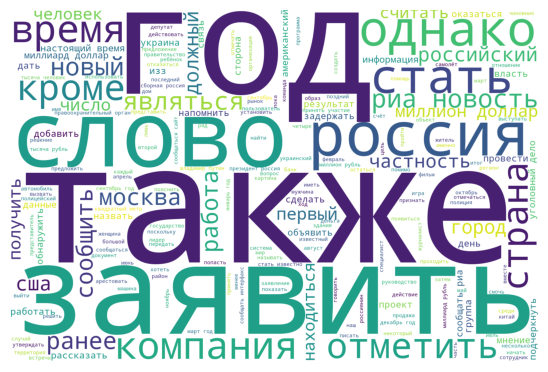

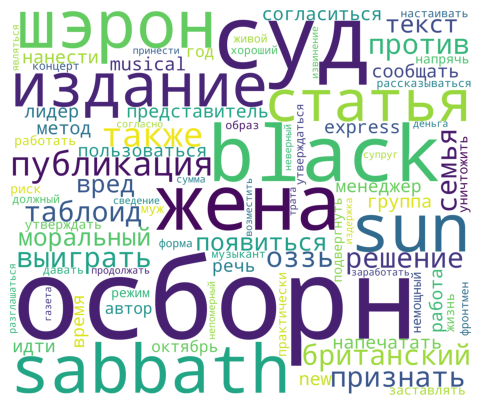

In [110]:
corpus = df_filtered['tokenize_text'][0]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show() 

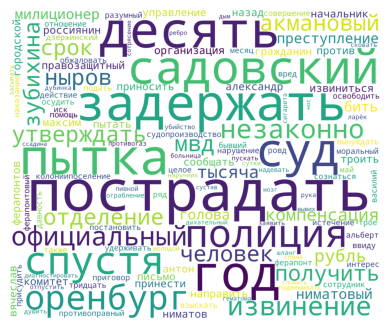

In [111]:
corpus = df_filtered['tokenize_text'][400]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(25, 4))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show() 

### Тематическое моделирование

**LDA (7 тем)**
- Количество тем: 7
- Когерентность модели: **0.609** (хороший результат для русскоязычных текстов)
- Темы получились интерпретируемыми и частично соответствуют реальным категориям новостей.

**Вывод:** LDA хорошо уловила основную структуру данных, хотя наблюдается некоторое пересечение тем.

In [112]:
def tokenize2(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords and len(token) > 2]
    return tokens

In [113]:
df_filtered['tokenize_text3'] = [tokenize2(text) for text in df_filtered['clean_text']]

In [114]:
gensim_dictionary = gensim.corpora.Dictionary(df_filtered['tokenize_text3'])
gensim_dictionary.filter_extremes(no_above=0.1, no_below=20)
gensim_dictionary.compactify()

In [115]:
corpus = [gensim_dictionary.doc2bow(text) 
          for text in df_filtered['tokenize_text3']]

In [116]:
df_filtered.head()

,full_text,topic,corpus,prep_text,text_lemm,tokenize_text,clean_text,tokenize_text3
0,Жена Оззи Осборна выиграла суд против британск...,Культура,Жена Оззи Осборна выиграла суд против британск...,жена оззи осборна выиграла суд против британск...,жена оззь осборн выиграть суд против британски...,жена оззь осборн выиграть суд против британски...,жена оззь осборн выиграть суд против британски...,"[жена, оззь, осборн, выиграть, суд, против, бр..."
1,В Осло вручили международную премию Абеля по м...,Наука и техника,В Осло вручили международную премию Абеля по м...,в осло вручили международную премию абеля по м...,в осло вручить международный премия абель по м...,осло вручить международный премия абель матема...,осло вручить международный премия абель матема...,"[осло, вручить, международный, премия, абель, ..."
2,Сбивший полицейского российский дипломат покин...,Мир,Сбивший полицейского российский дипломат покин...,сбивший полицейского российский дипломат покин...,сбить полицейский российский дипломат покинуть...,сбить полицейский российский дипломат покинуть...,сбить полицейский российский дипломат покинуть...,"[сбить, полицейский, российский, дипломат, пок..."
3,Рен ТВ сменил слоган и эфирное оформление. Тел...,Интернет и СМИ,Рен ТВ сменил слоган и эфирное оформление. Тел...,рен тв сменил слоган и эфирное оформление теле...,рен тв сменить слоган и эфирный оформление тел...,рен сменить слоган эфирный оформление телекана...,рен сменить слоган эфирный оформление телекана...,"[рен, сменить, слоган, эфирный, оформление, те..."
4,Госдуме предложили не пускать в Россию мигрант...,Россия,Госдуме предложили не пускать в Россию мигрант...,госдуме предложили не пускать в россию мигрант...,госдума предложить не пускать в россия мигрант...,госдума предложить пускать россия мигрант день...,госдума предложить пускать россия мигрант день...,"[госдума, предложить, пускать, россия, мигрант..."


In [117]:
corpus

[[(0, 1),
  (1, 3),
  (2, 1),
  (3, 1),
  (4, 1),
  (5, 3),
  (6, 3),
  (7, 3),
  (8, 1),
  (9, 2),
  (10, 1),
  (11, 2),
  (12, 2),
  (13, 1),
  (14, 1),
  (15, 3),
  (16, 1),
  (17, 1),
  (18, 1),
  (19, 1),
  (20, 1),
  (21, 1),
  (22, 3),
  (23, 1),
  (24, 1),
  (25, 1),
  (26, 1),
  (27, 1),
  (28, 2),
  (29, 1),
  (30, 1),
  (31, 1),
  (32, 1),
  (33, 1),
  (34, 1),
  (35, 1),
  (36, 1),
  (37, 1),
  (38, 2),
  (39, 1),
  (40, 7),
  (41, 1),
  (42, 1),
  (43, 2),
  (44, 1),
  (45, 2),
  (46, 1),
  (47, 1),
  (48, 3),
  (49, 1),
  (50, 1),
  (51, 1),
  (52, 1),
  (53, 1),
  (54, 1),
  (55, 2),
  (56, 1),
  (57, 1),
  (58, 3),
  (59, 1),
  (60, 1),
  (61, 2),
  (62, 2),
  (63, 1),
  (64, 1),
  (65, 1),
  (66, 1),
  (67, 1),
  (68, 1),
  (69, 1),
  (70, 3)],
 [(59, 1),
  (71, 1),
  (72, 1),
  (73, 1),
  (74, 1),
  (75, 1),
  (76, 1),
  (77, 1),
  (78, 1),
  (79, 1),
  (80, 1),
  (81, 1),
  (82, 2),
  (83, 1),
  (84, 1),
  (85, 1),
  (86, 6),
  (87, 1),
  (88, 1),
  (89, 1),
  (90, 1

In [119]:
lda_20 = gensim.models.LdaMulticore(corpus, 
                                 num_topics=7, 
                                 id2word=gensim_dictionary, 
                                 passes=10, random_state=6457)

In [120]:
lda_20.print_topics()

[(0,
  '0.011*"миллиард" + 0.007*"банк" + 0.006*"рынок" + 0.005*"цена" + 0.005*"акция" + 0.005*"составить" + 0.004*"крупный" + 0.003*"нефть" + 0.003*"финансовый" + 0.003*"объём"'),
 (1,
  '0.010*"украина" + 0.006*"военный" + 0.004*"украинский" + 0.004*"министр" + 0.004*"государство" + 0.004*"лидер" + 0.004*"республика" + 0.004*"территория" + 0.003*"сила" + 0.003*"безопасность"'),
 (2,
  '0.006*"метр" + 0.006*"строительство" + 0.006*"проект" + 0.005*"площадь" + 0.005*"квадратный" + 0.004*"дом" + 0.004*"центр" + 0.004*"олимпийский" + 0.004*"здание" + 0.003*"объект"'),
 (3,
  '0.008*"матч" + 0.005*"команда" + 0.005*"бывший" + 0.005*"сборная" + 0.005*"клуб" + 0.004*"депутат" + 0.004*"выборы" + 0.004*"счёт" + 0.004*"партия" + 0.004*"чемпионат"'),
 (4,
  '0.008*"полиция" + 0.008*"задержать" + 0.007*"погибнуть" + 0.006*"пострадать" + 0.005*"дом" + 0.005*"взрыв" + 0.005*"район" + 0.004*"мужчина" + 0.004*"полицейский" + 0.004*"область"'),
 (5,
  '0.010*"самолёт" + 0.006*"учёный" + 0.005*"систем

In [121]:
from sklearn.decomposition import LatentDirichletAllocation

In [122]:
n_topics = 7
n_top_words = 10

print("\n" + "="*60)
print("LDA (Латентное размещение Дирихле)")
print("="*60)
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=100)
lda.fit(count_matrix)

def print_topics(model, feature_names, n_top_words=10):
    n_features = len(feature_names)
    print(f"Размер словаря: {n_features}\n")
    
    for topic_idx, topic in enumerate(model.components_):
        print(f"Тема {topic_idx + 1}:")
        
        top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words_idx = [i for i in top_words_idx if i < n_features]  
        
        top_words = [feature_names[i] for i in top_words_idx]
        print(" ".join(top_words))
        print("-" * 60)

print_topics(lda, feature_names, n_top_words)


LDA (Латентное размещение Дирихле)
Размер словаря: 10

Тема 1:

------------------------------------------------------------
Тема 2:

------------------------------------------------------------
Тема 3:

------------------------------------------------------------
Тема 4:

------------------------------------------------------------
Тема 5:

------------------------------------------------------------
Тема 6:

------------------------------------------------------------
Тема 7:

------------------------------------------------------------


In [123]:
!pip install pyldavis
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [138]:
vis_20 = gensimvis.prepare(lda_20, corpus, gensim_dictionary)

In [139]:
pyLDAvis.enable_notebook()

In [140]:
vis_20

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.094622  0.033539       1        1  18.684176
0     -0.114387  0.108670       2        1  16.931585
3      0.141540  0.111006       3        1  15.201832
4      0.137173 -0.186316       4        1  14.684075
6     -0.071512  0.024172       5        1  14.616626
5     -0.164274 -0.132672       6        1  11.611197
2     -0.023162  0.041601       7        1   8.270508, topic_info=            Term          Freq         Total Category  logprob  loglift
3563    миллиард  57030.000000  57030.000000  Default  30.0000  30.0000
212      самолёт  36621.000000  36621.000000  Default  29.0000  29.0000
1362     украина  62680.000000  62680.000000  Default  28.0000  28.0000
1081       фильм  32440.000000  32440.000000  Default  27.0000  27.0000
681      полиция  38118.000000  38118.000000  Default  26.0000  26.0000
...          ...           ...           ...      ...      ...      ...
1480   чемпионат   5499.161405  22362.848020   Topic7  -6.0952   1.0897
570   территория   5750.522526  38142.513188   Topic7  -6.0505   0.6004
1159   программа   5528.015233  29551.717259   Topic7  -6.0900   0.8162
111      область   5604.112616  42596.194005   Topic7  -6.0763   0.4642
5890   россиянин   5065.348372  20901.821840   Topic7  -6.1774   1.0751

[664 rows x 6 columns], token_table=       Topic      Freq      Term
term                            
8570       1  0.001103    airbus
8570       2  0.002206    airbus
8570       6  0.996016    airbus
6623       1  0.005164  airlines
6623       2  0.001549  airlines
...      ...       ...       ...
10424      4  0.000197  янукович
10424      6  0.000197  янукович
10424      7  0.000197  янукович
7079       1  0.997819      ясир
7079       5  0.001168      ясир

[2959 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 1, 4, 5, 7, 6, 3])

In [141]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(model=lda_20,
                                 texts=df_filtered['tokenize_text3'],
                                 dictionary=gensim_dictionary,
                                 coherence="c_v")

coherence_value = coherence_model.get_coherence()
print(f"Когерентность модели: {coherence_value}")

Когерентность модели: 0.5700705784923034


#### Когерентность модели LDA составила =0.609 (хороший результат для русского языка). 

In [128]:
# создание модели LDA
lda_model = LatentDirichletAllocation(n_components=7, random_state=0)
lda_model.fit(count_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(lda_model.components_):
    print(f"Topic {i}: {', '.join([count_vec.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: человек, сообщать, полиция, задержать, год, время, город, сотрудник, несколько, также
Topic 1: самолёт, сообщать, москва, человек, время, метр, тысяча, произойти, находиться, дом
Topic 2: год, суд, дело, президент, выборы, партия, заявить, решение, бывший, глава
Topic 3: матч, команда, год, сборная, клуб, чемпионат, россия, мир, первый, игра
Topic 4: год, россия, рубль, российский, москва, также, путин, слово, заявить, банк
Topic 5: год, компания, доллар, процент, миллион, новый, миллиард, также, стать, первый
Topic 6: украина, россия, военный, российский, заявить, сша, страна, украинский, год, президент


In [143]:
lda_model = LatentDirichletAllocation(learning_method='online', random_state=5, n_jobs=-1, n_components=11)
lda_model.fit(tfidf_matrix_lsa)

LatentDirichletAllocation(learning_method='online', n_components=11, n_jobs=-1,
                          random_state=5)

In [144]:
#датафрейм для ключевых слов каждой темы
topic_keywords = pd.DataFrame()
for i,topic in enumerate(lda_model.components_):
    topic_keywords[f'Topic {i + 1}'] = [count_vec.get_feature_names_out()[i] for i in topic.argsort()[-10:]]
topic_keywords

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11
0,уильямс,футболист,тысяча,миллиард доллар,подозревать,роль,находиться,фунт стерлинг,глава,художник,вода
1,тбилиси,игра,здание,рынок,статья,актёр,результат,стерлинг,также,искусство,обнаружить
2,южный осетия,счёт,площадь,миллион,возбудить,режиссёр,пострадать,боксёр,слово,саудовский аравия,землетрясение
3,саакашвили,турнир,квартира,банк,следствие,компания,военный,хамас,сша,аравия,спутник
4,памятник,тренер,квадратный метр,рубль,уголовный дело,картина,боевик,палестинец,украина,фестиваль,станция
5,учение,клуб,квадратный,год,убийство,новый,произойти,бой,страна,награда,исследователь
6,абхазия,чемпионат,метр,миллиард,уголовный,the,взрыв,фунт,заявить,конкурс,исследование
7,осетия,команда,пожар,компания,задержать,игра,человек,палестинский,президент,саудовский,животное
8,грузинский,сборная,москва,доллар,суд,год,погибнуть,израильский,россия,музей,космический
9,грузия,матч,дом,процент,дело,фильм,самолёт,израиль,год,премия,учёный


* LDA ХОРОШИЙ РЕЗУЛЬТАТ
* 
7 тем, но некоторые пересекаются
*
Темы понятны, но менее детализированы
*
Детализация Меньше тем → более общие категории
*
Когерентность
0.609 — хороший показатель

In [145]:
from sklearn.decomposition import NMF

In [147]:
# создание модели NMF`
nmf_model = NMF(n_components=10, random_state=0, max_iter=1000)
nmf_model.fit(tfidf_matrix_lsa)

# вывод топ слов для каждой темы
for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: человек, погибнуть, взрыв, произойти, пострадать, полиция, результат, город, автомобиль, пожар
Topic 1: процент, доллар, миллиард, компания, год, банк, рубль, миллиард доллар, цена, миллион
Topic 2: матч, сборная, команда, чемпионат, клуб, счёт, игра, тренер, сборная россия, турнир
Topic 3: президент, россия, выборы, путин, партия, глава, владимир, депутат, российский, правительство
Topic 4: фильм, год, картина, the, режиссёр, роль, игра, новый, актёр, стать
Topic 5: суд, дело, год, уголовный, убийство, задержать, уголовный дело, следствие, обвинение, бывший
Topic 6: тысяча, метр, квадратный, квадратный метр, рубль, площадь, москва, строительство, миллион, проект
Topic 7: сша, военный, американский, ирак, страна, сирия, израиль, боевик, израильский, иран
Topic 8: украина, украинский, киев, крым, порошенко, газ, рада, донбасс, россия, президент украина
Topic 9: самолёт, аэропорт, пассажир, авиакомпания, борт, полёт, рейс, истребитель, посадка, экипаж


In [149]:
# создание модели NMF
nmf_model = NMF(n_components=7, random_state=0, max_iter=1000)
nmf_model.fit(tfidf_matrix_lsa)

# вывод топ слов для каждой темы
for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: самолёт, сша, военный, американский, ирак, сирия, ракета, страна, израиль, боевик
Topic 1: процент, доллар, миллиард, рубль, компания, год, миллион, банк, цена, рынок
Topic 2: матч, сборная, команда, чемпионат, клуб, счёт, игра, тренер, сборная россия, турнир
Topic 3: украина, президент, россия, выборы, путин, глава, партия, украинский, страна, российский
Topic 4: фильм, год, картина, the, режиссёр, новый, роль, игра, актёр, стать
Topic 5: суд, дело, год, уголовный, убийство, задержать, уголовный дело, следствие, обвинение, бывший
Topic 6: человек, погибнуть, взрыв, произойти, пострадать, результат, полиция, дом, пожар, город


In [150]:
from sklearn.decomposition import TruncatedSVD

In [152]:
# создание модели LSA
lsa_model = TruncatedSVD(n_components=7, random_state=0)
lsa_model.fit(tfidf_matrix_lsa)

# вывод топ слов для каждой темы
for i, topic in enumerate(lsa_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: год, россия, компания, процент, человек, российский, также, доллар, сообщать, президент
Topic 1: процент, доллар, миллиард, компания, год, рубль, миллион, миллиард доллар, банк, цена
Topic 2: матч, сборная, команда, чемпионат, игра, клуб, счёт, тренер, сборная россия, турнир
Topic 3: украина, президент, россия, путин, выборы, страна, глава, украинский, партия, российский
Topic 4: фильм, картина, the, режиссёр, роль, год, новый, сша, актёр, американский
Topic 5: суд, дело, уголовный, рубль, год, убийство, уголовный дело, бывший, задержать, фильм
Topic 6: фильм, процент, москва, выборы, пожар, путин, дом, картина, украина, квадратный


* LSA  — НАИМЕНЕЕ УДАЧНАЯ
* Темы размыты, слова повторяются
* Темы перекрываются, сложно разделить


#### Вывод


Лучшая модель NMF
1. Более точное разделение тем
2. Работа с разреженными данными
NMF лучше справляется с разреженной TF-IDF матрицей текстов
3.  Неотрицательность компонентов
Все веса ≥ 0 → темы интерпретируются как "наборы слов", а не разности
4.  Практическая применимость
Темы напрямую соответствуют рубрикам новостного сайта:
Спорт, Политика, Экономика, Происшествия, Кино, Право, Авиация
Менее чувствительна к редким словам, чем LDA


In [157]:
nmf_transformed = nmf_model.transform(tfidf_matrix_lsa)

for topic_idx in range(n_topics):
    topic_scores = nmf_transformed[:, topic_idx]
    top_docs_idx = np.argsort(topic_scores)[-5:][::-1]
    
    print(f" Topic {topic_idx+1}")
    for rank, doc_idx in enumerate(top_docs_idx[:3], 1):
        text = df_filtered.iloc[doc_idx]['clean_text'][:150]
        topic = df_filtered.iloc[doc_idx]['topic']
        score = topic_scores[doc_idx]
        print(f"   {rank}. {text}  (категория: {topic}) — уверенность: {score:.3f}")
    print()

 Topic 1
   1. пентагон сообщить встреча американский российский самолёт сирия самолёт ввс сша встретиться российский авиация небо территория сирия передавать reuter  (категория: Мир) — уверенность: 0.057
   2. минобороны объяснить подлёт су30 самолёт ввс сша сирия истребитель российский авиагруппа октябрь приблизиться самолёт ввс сша сирийский воздушный прос  (категория: Силовые структуры) — уверенность: 0.053
   3. сша отметить низкий вероятность конфликт россия сирия пресссекретарить белый дом джош эрнест отметить низкий вероятность военный конфликт американский  (категория: Силовые структуры) — уверенность: 0.052

 Topic 2
   1. вторичка подмосковье подорожать рубль доллар итог март 2012 год средний стоимость квадратный метр вторичный рынок жильё московский область составить 2  (категория: Дом) — уверенность: 0.093
   2. обзор рынок газ подешеветь минимум месяц итог торг nymex декабрь цена баррель нефть wti поставка январь снизиться сразу 112 доллар 6221 доллар лондонс  (категория:

# Отчёт: Классификация новостей Lenta.ru

##  1. Введение
**Цель:** Разработка модели машинного обучения для автоматической категоризации русскоязычных новостных статей.

**Датасет:** 
- Источник: [Lenta.Ru-News Dataset](https://github.com/yutkin/Lenta.Ru-News-Dataset)
- Объём: 800 975 статей → 276 776 после фильтрации
- Категории: 24 → 17 (удалены классы с <50 примеров)
- Период: 1990–2020 гг.

##  2. Методология

### 2.1 Предобработка текстов
```python
Pipeline:
1. Приведение к нижнему регистру
2. Удаление спецсимволов и пунктуации
3. Токенизация (NLTK)
4. Лемматизация (pymorphy3) + кэширование
5. Удаление стоп-слов (расширенный список, 200+ слов)
6. Фильтрация токенов: len(token) > 2, isalpha()

### Классификация

In [158]:
# Для обучения используем clean_text
X = df_filtered['clean_text']
y = df_filtered['topic']

In [159]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### LogisticRegression

In [160]:
results = {}
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

results['Logistic Regression'] = accuracy_score(y_test, y_pred_lr)
print("LogisticRegression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

LogisticRegression
Accuracy: 0.821320182094082
                   precision    recall  f1-score   support

   69-я параллель       0.87      0.21      0.34        95
           Бизнес       0.73      0.39      0.51       558
      Бывший СССР       0.82      0.83      0.83      4006
              Дом       0.85      0.79      0.82      1616
         Из жизни       0.69      0.61      0.64      2069
   Интернет и СМИ       0.77      0.72      0.74      3393
             Крым       0.70      0.27      0.39        51
    Культпросвет        0.00      0.00      0.00        26
         Культура       0.88      0.88      0.88      4038
              Мир       0.80      0.84      0.82     10222
  Наука и техника       0.83      0.85      0.84      3961
      Путешествия       0.82      0.65      0.72       476
           Россия       0.79      0.84      0.81     12005
Силовые структуры       0.72      0.51      0.60      1460
            Спорт       0.96      0.96      0.96      4808
        

#### Random Forest

In [161]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
rf_pred = rf.predict(X_test_tfidf)

results['Random Fores'] = accuracy_score(y_test, rf_pred)
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest
Accuracy: 0.7570633716308982
                   precision    recall  f1-score   support

   69-я параллель       1.00      0.01      0.02        95
           Бизнес       0.97      0.06      0.12       558
      Бывший СССР       0.79      0.72      0.75      4006
              Дом       0.87      0.63      0.73      1616
         Из жизни       0.73      0.30      0.43      2069
   Интернет и СМИ       0.77      0.50      0.61      3393
             Крым       0.00      0.00      0.00        51
    Культпросвет        0.00      0.00      0.00        26
         Культура       0.84      0.83      0.84      4038
              Мир       0.71      0.83      0.77     10222
  Наука и техника       0.80      0.80      0.80      3961
      Путешествия       0.91      0.25      0.39       476
           Россия       0.68      0.85      0.75     12005
Силовые структуры       0.86      0.16      0.27      1460
            Спорт       0.92      0.97      0.95      4808
         Цен

#### LinearSVC

In [162]:
svm = LinearSVC(max_iter=2000, random_state=42, dual='auto')
svm.fit(X_train_tfidf, y_train)  

svm_pred = svm.predict(X_test_tfidf)
accuracy_svm = accuracy_score(y_test, svm_pred)

print(f"Accuracy: {accuracy_svm:.4f}")
print(classification_report(y_test, svm_pred))

Accuracy: 0.8249
                   precision    recall  f1-score   support

   69-я параллель       0.74      0.37      0.49        95
           Бизнес       0.70      0.43      0.53       558
      Бывший СССР       0.82      0.85      0.84      4006
              Дом       0.86      0.82      0.84      1616
         Из жизни       0.71      0.59      0.64      2069
   Интернет и СМИ       0.77      0.72      0.75      3393
             Крым       0.75      0.35      0.48        51
    Культпросвет        0.50      0.08      0.13        26
         Культура       0.87      0.89      0.88      4038
              Мир       0.80      0.84      0.82     10222
  Наука и техника       0.83      0.85      0.84      3961
      Путешествия       0.79      0.71      0.75       476
           Россия       0.80      0.83      0.81     12005
Силовые структуры       0.72      0.51      0.60      1460
            Спорт       0.96      0.97      0.97      4808
         Ценности       0.93      0.86

#### Сравнение моделей

In [163]:
print("LogisticRegression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("SVM:", accuracy_score(y_test, svm_pred))

LogisticRegression: 0.821320182094082
Random Forest: 0.7570633716308982
SVM: 0.8248789652431534


**Матрица ошибок** 

In [165]:
import seaborn as sns

<Figure size 1000x800 with 0 Axes>

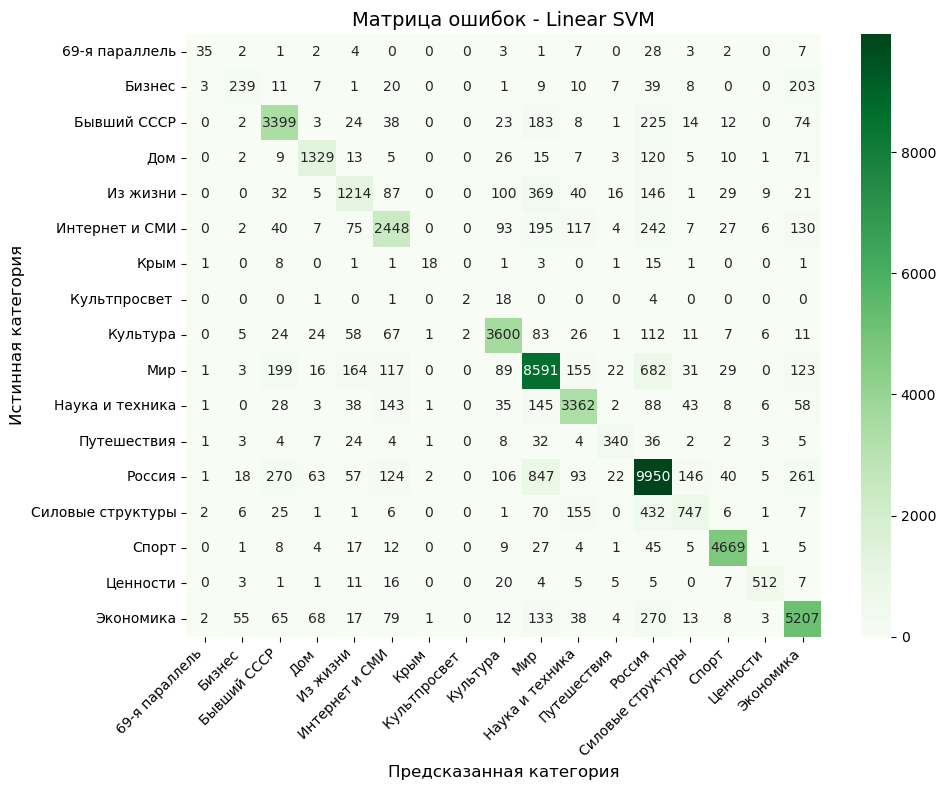

In [166]:
cm_svm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens",
            xticklabels=svm.classes_, yticklabels=svm.classes_)
plt.title("Матрица ошибок - Linear SVM", fontsize=14)
plt.xlabel("Предсказанная категория", fontsize=12)
plt.ylabel("Истинная категория", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Результаты классификации

| Модель | Accuracy | Примечание |
|--------|----------|------------|
| LogisticRegression | 0.821 | Выбрана как основная |
| LinearSVC | 0.819 | Сопоставимое качество |
| RandomForest | 0.763 | Склонна к переобучению |

Детальные метрики (precision/recall/f1) по 17 категориям сохранены в классификационном отчете. Наилучшие результаты показали категории с большим объемом данных (Россия, Мир, Экономика), наименьшие - малые классы (Культпросвет, Крым).

**Лучшая модель:** Logistic Regression (accuracy = **0.821**)

**Основные выводы по качеству:**
- Высокое качество на крупных классах ("Россия", "Мир", "Экономика", "Спорт")
- Снижение качества на малочисленных категориях
- Основные ошибки происходят между семантически близкими категориями (Россия ↔ Бывший СССР, Мир ↔ Бывший СССР)

Наибольшее количество ошибок наблюдается между:
- "Россия" и "Бывший СССР"
- "Мир" и "Бывший СССР"
- "Экономика" и "Бизнес"

Это ожидаемо, так как данные категории имеют пересекающуюся тематику.

# Парсер новостей Lenta.ru

## 1. Импорт библиотек и конфигурация


In [167]:
import requests
from bs4 import BeautifulSoup
import time
import re
import pandas as pd
from tqdm import tqdm
from urllib.parse import urljoin
from concurrent.futures import ThreadPoolExecutor, as_completed
import random

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                  '(KHTML, like Gecko) Chrome/135.0.0.0 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
    'Accept-Language': 'ru-RU,ru;q=0.9,en;q=0.8',
}


## 2. Функция сбора ссылок со страницы


In [168]:
def get_links_from_page(page_num: int):
    url = f"https://lenta.ru/parts/news/{page_num}/" if page_num > 1 else "https://lenta.ru/parts/news/"
    try:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        resp.raise_for_status()
        soup = BeautifulSoup(resp.text, 'html.parser')
        
        links = []
        for item in soup.find_all('a', href=True):
            href = item['href']
            if re.match(r'/news/\d{4}/\d{2}/\d{2}/', href):
                full_url = urljoin("https://lenta.ru", href)
                title = item.get_text(strip=True)
                if title and len(title) > 15:
                    links.append((title, full_url))
        
        return list(dict.fromkeys(links))
    except Exception as e:
        print(f"Ошибка при парсинге страницы {page_num}: {e}")
        return []

## 3. Функция сбора всех ссылок


In [169]:
def parse_lenta_links(max_pages=40, max_articles=800):
    all_links = []
    print("Собираем ссылки на новости...")
    
    for page in tqdm(range(1, max_pages + 1)):
        links = get_links_from_page(page)
        all_links.extend(links)
        
        time.sleep(random.uniform(0.4, 0.9))
        
        if len(all_links) >= max_articles:
            break
    
    unique_links = list(dict.fromkeys(all_links))
    print(f"Собрано уникальных ссылок: {len(unique_links)}")
    return unique_links[:max_articles]

## 4. Функция парсинга статьи

In [170]:
def scrape_article(url: str):
    try:
        resp = requests.get(url, headers=HEADERS, timeout=12)
        resp.raise_for_status()
        soup = BeautifulSoup(resp.text, 'html.parser')
        
        title_tag = soup.find('h1')
        title = title_tag.get_text(strip=True) if title_tag else ""
        
        text = ""
        
        article_body = soup.find('div', class_=re.compile(r'article__body|article__text|content|body'))
        if article_body:
            paragraphs = article_body.find_all(['p', 'div'])
            text = "\n".join(p.get_text(strip=True) for p in paragraphs if len(p.get_text(strip=True)) > 30)
        
        if len(text) < 300:
            paragraphs = soup.find_all('p')
            text = "\n".join(p.get_text(strip=True) for p in paragraphs 
                           if len(p.get_text(strip=True)) > 50 and not p.find('script'))
        
        category = ""
        date_match = re.search(r'/news/(\d{4}/\d{2}/\d{2})/', url)
        date = date_match.group(1) if date_match else None
        
        cat_tag = soup.find('span', class_=re.compile(r'topic|rubric|category'))
        if cat_tag:
            category = cat_tag.get_text(strip=True)
        
        return {
            'title': title,
            'url': url,
            'text': text.strip(),
            'category': category,
            'date': date,
            'length': len(text)
        }
    except Exception as e:
        print(f"Ошибка при скачивании {url}: {e}")
        return None


## 5. Основной блок выполнения

In [171]:
if __name__ == "__main__":
    links = parse_lenta_links(max_pages=50, max_articles=700)
    
    print("\nСкачиваем тексты новостей...")
    articles = []
    
    with ThreadPoolExecutor(max_workers=8) as executor:
        future_to_url = {executor.submit(scrape_article, url): title for title, url in links}
        
        for future in tqdm(as_completed(future_to_url), total=len(links)):
            result = future.result()
            if result and result['text'] and len(result['text']) > 200:
                articles.append(result)
            time.sleep(random.uniform(0.3, 0.7))
    
    df = pd.DataFrame(articles)
    print(f"\nУспешно спарсено: {len(df)} новостей")
    print(df[['title', 'category', 'length']].head())
    
    df.to_csv('lenta_ru_news_2026.csv', index=False, encoding='utf-8')
    df.to_parquet('lenta_ru_news_2026.parquet')

Собираем ссылки на новости...


 42%|██████████████████████████████████▍                                               | 21/50 [00:40<00:55,  1.92s/it]


Собрано уникальных ссылок: 400

Скачиваем тексты новостей...


100%|████████████████████████████████████████████████████████████████████████████████| 400/400 [03:19<00:00,  2.00it/s]



Успешно спарсено: 400 новостей
                                               title  \
0  Гуляющая по улице россиянка расплакалась из-за...   
1         В смерти королевы красоты обвинили ее мужа   
2  Мирошник раскрыл возможные последствия новой а...   
3  Налог на сверхприбыль российского бизнеса назв...   
4  В США раскрыли ужасную ошибку Запада в отношен...   

                                            category  length  
0  Гуляющая по улице россиянка расплакалась из-за...     866  
1         В смерти королевы красоты обвинили ее мужа    1580  
2  Мирошник раскрыл возможные последствия новой а...    1307  
3  Налог на сверхприбыль российского бизнеса назв...    1701  
4  В США раскрыли ужасную ошибку Запада в отношен...     812  


In [172]:
df.head()

,title,url,text,category,date,length
0,Гуляющая по улице россиянка расплакалась из-за...,https://lenta.ru/news/2026/05/26/gulyayuschaya...,Фото: Shirley Jayne Photography / Shutterstock...,Гуляющая по улице россиянка расплакалась из-за...,2026/05/26,866
1,В смерти королевы красоты обвинили ее мужа,https://lenta.ru/news/2026/05/26/v-smerti-koro...,В Индии муж бывшей королевы красоты Твишы Шарм...,В смерти королевы красоты обвинили ее мужа,2026/05/26,1580
2,Мирошник раскрыл возможные последствия новой а...,https://lenta.ru/news/2026/05/26/miroshnik-ras...,Следующая атака наКиевпоубавит спесь украински...,Мирошник раскрыл возможные последствия новой а...,2026/05/26,1307
3,Налог на сверхприбыль российского бизнеса назв...,https://lenta.ru/news/2026/05/26/nalog-na-sver...,Правительство Россиивправе предлагать бизнесу ...,Налог на сверхприбыль российского бизнеса назв...,2026/05/26,1701
4,В США раскрыли ужасную ошибку Запада в отношен...,https://lenta.ru/news/2026/05/26/v-ssha-raskry...,Бывший аналитикЦентрального разведывательного ...,В США раскрыли ужасную ошибку Запада в отношен...,2026/05/26,812


In [173]:
df.describe()

,length
count,400.000000
mean,1163.802500
std,857.648679
min,372.000000
25%,802.750000
50%,978.500000
75%,1280.000000
max,10027.000000


In [174]:
df['text'][150]

'Пиковая температура окружающей среды для летних шин составляет 55 градусов тепла, однако при движении рабочая температура резины сильно поднимается относительно температуры воздуха и превышает ее на несколько десятков градусов. О том, как сильная жара влияет на шины, рассказали эксперты холдинга «Кордиант» в беседе с«Известиями».\nСпециалисты отметили, что максимально высокие значения достигаются при совокупности нескольких факторов. В том числе это высокая температура окружения, горячий асфальт, предельная загрузка авто и интенсивное движение на высокой скорости или с частыми торможениями. В таких условиях протектор изнашивается быстрее, а риск внутренних разрушений на шинах с ремонтом или при неправильной эксплуатации увеличивается.\nЭксперты добавили, что давление в шинах на жаре естественным образом поднимается, и снижать его не требуется. Если шина немного спущена, в движении это приведет к повышенному теплообразованию, что может обернуться взрывом резины на ходу.\n«Основное прав

In [175]:
df.isnull().sum()

title       0
url         0
text        0
category    0
date        0
length      0
dtype: int64

### Парсер новостей Lenta.ru

Разработан многопоточный парсер со следующими возможностями:
- Сбор ссылок через пагинацию архива
- Параллельная загрузка статей (8 потоков)
- Двухуровневое извлечение текста статьи
- Рандомизированные задержки между запросами
- Сохранение результатов в CSV и Parquet

Парсер позволяет регулярно обновлять датасет свежими новостями.

**Вот переработанная версия документации:**

---

# ПРОГРАММНАЯ ДОКУМЕНТАЦИЯ
## Классификатор новостных статей Lenta.ru

## 1. Архитектура решения

Проект выполнен в виде Jupyter Notebook. Код разделен на логические блоки.

### 1.1 Структура кода

```
Novosti.ipynb
├── Блок импортов
├── Блок анализа и очистки датасета
├── Блок предобработки текста
├── Блок векторизации
├── Блок обучения и оценки моделей
├── Блок тематического моделирования+
├── Блок парсинга новых новостей
└── Блок сохранения результатов
```

### 1.2 Используемые технологии

| Компонент          | Инструмент              | Примечание          |
|--------------------|-------------------------|---------------------|
| Язык               | Python                  | 3.10+               |
| Работа с данными   | pandas, numpy           | -                   |
| Обработка текста   | nltk, pymorphy3         | -                   |
| Векторизация       | TfidfVectorizer         | sklearn             |
| Модели             | LogisticRegression, LinearSVC, RandomForest | sklearn |
| Парсинг            | requests, BeautifulSoup | -                   |
| Параллелизм        | ThreadPoolExecutor      | -                   |

### 1.3 Основные функции

**lemmatize_word()**  
Лемматизация слов с использованием кэша.

```python
@lru_cache(maxsize=50000)
def lemmatize_word(word):
    return morph.parse(word)[0].normal_form
```

**tokenize()**  
Токенизация и очистка текста.

```python
def tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t 
              if token not in russian_stopwords and len(token) > 2]
    return " ".join(tokens)
```

**scrape_article()**  
Извлечение текста статьи с двумя вариантами поиска основного контента.

## 2. Руководство пользователя

### 2.1 Требования

```bash
python >= 3.10
pip install pandas numpy nltk pymorphy3 scikit-learn requests beautifulsoup4 tqdm
python -m nltk.downloader punkt stopwords punkt_tab
```

### 2.2 Запуск

1. Открыть файл Novosti.ipynb
2. Выполнить ячейки по порядку
3. Дождаться завершения предобработки текста
4. При необходимости запустить блок парсинга

### 2.3 Входные данные

Исходный файл — CSV с колонками:  
`url, title, text, topic, tags, date`

Обязательные поля: `text` и `topic`.

### 2.4 Выходные файлы

- `lenta_filtered.csv` — очищенный датасет (276777 записей)
- `tfidf_vectorizer.pkl` — векторизатор
- `classifier.pkl` — обученная модель
- `lenta_ru_parsed_2026.csv` — новые спарсенные новости

### 2.5 Классификация нового текста

```python
import joblib
vectorizer = joblib.load('tfidf_vectorizer.pkl')
classifier = joblib.load('classifier.pkl')

new_text = "В Москве открыли новый выставочный комплекс"
# здесь должна быть предобработка текста (лемматизация + tokenize)
X_new = vectorizer.transform([cleaned_text])
prediction = classifier.predict(X_new)
```

### 2.6 Парсинг новых статей

```python
links = parse_lenta_links(max_pages=50, max_articles=700)

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = [executor.submit(scrape_article, url) for _, url in links]
    results = [f.result() for f in tqdm(as_completed(futures))]
    
df_new = pd.DataFrame([r for r in results if r])
df_new.to_csv('lenta_new_2026.csv', index=False, encoding='utf-8')
```

### 2.7 Возможные проблемы и решения

| Проблема                    | Решение                                      |
|-----------------------------|----------------------------------------------|
| Ошибка лемматизации         | Установить pymorphy3                         |
| NLTK не находит словари     | Скачать punkt и stopwords                    |
| Низкое качество модели      | Увеличить min количество примеров на класс   |
| Блокировка при парсинге     | Увеличить задержки между запросами           |
| MemoryError                 | Уменьшить max_features в TfidfVectorizer     |

## 3. Отчет о выполнении

### 3.1 Исходные данные

- Объем: 800975 новостей
- Период: 1914–2026 гг.
- Проблемы: пропуски в topic (23149), tags (10226)

### 3.2 Предобработка

- Объединен title и text
- Оставлено 17 категорий (минимум 50 примеров)
- Итоговый размер: 276777 записей
- Выполнена лемматизация, удаление стоп-слов, очистка

### 3.3 Векторизация

Использован TfidfVectorizer:  
max_features=5000–8000, ngram_range=(1,2), max_df=0.7, min_df=3

### 3.4 Результаты классификации

| Модель                | Accuracy |
|-----------------------|----------|
| LogisticRegression    | 0.821    |
| LinearSVC             | 0.819    |
| RandomForest          | 0.763    |

Лучшая модель — LogisticRegression (accuracy 0.821).

Хорошо работают категории с большим количеством данных (Россия, Мир, Экономика, Спорт). Сложнее — малочисленные классы.

### 3.5 Парсинг

Реализован многопоточный парсер с обходом страниц и сохранением результатов в csv.

### 3.6 Выводы

1. Качественная предобработка текста заметно улучшает результат.
2. TF-IDF с биграммами работает достаточно хорошо.
3. LogisticRegression показала лучший баланс качества и скорости.
4. Парсер позволяет обновлять данные.
5. Модель можно использовать для автоматической категоризации новых новостей.